In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# --- PATH CONFIGURATION ---
CSV_PATH = "data/final_training_data.csv"

MODELS_DIR = "../controller/models_dist"
os.makedirs(MODELS_DIR, exist_ok=True)

print(" Libraries Loaded & Paths Configured")

 Libraries Loaded & Paths Configured


In [4]:
print(f"Loading Dataset: {CSV_PATH}...")

if not os.path.exists(CSV_PATH):
    print(f"Error: {CSV_PATH} not found. Run 'Data_Preprocessing_Lab.ipynb' first!")
else:
    df = pd.read_csv(CSV_PATH)
    
    # Column Mapping
    column_map = {
        'PPS': 'pps',
        'BPS': 'bps',
        'IP_Entropy': 'ip_entropy',
        'Avg_Packet_Size': 'avg_packet_size',
        'Label': 'label'
    }
    df = df.rename(columns=column_map)
    
    # Extract Features
    required_cols = ['pps', 'bps', 'ip_entropy', 'avg_packet_size']
    X = df[required_cols].values
    y = df['label'].values
    
    print(f" Loaded {len(df)} samples.")
    print(f"   Features: {required_cols}")

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Save Scaler for the Controller
    joblib.dump(scaler, f"{MODELS_DIR}/scaler.pkl")
    print(f"Scaler saved to {MODELS_DIR}/scaler.pkl")
    
    # Save Processed Data for other Notebooks
    np.save("data/processed_features.npy", X_scaled)
    np.save("data/processed_labels.npy", y)
    print("Processed numpy arrays saved to data/")

    # Split for Training
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    print(f"   Training Set: {X_train.shape[0]} samples")

Loading Dataset: data/final_training_data.csv...
 Loaded 23554 samples.
   Features: ['pps', 'bps', 'ip_entropy', 'avg_packet_size']
Scaler saved to ../controller/models_dist/scaler.pkl
Processed numpy arrays saved to data/
   Training Set: 18843 samples



Training Random Forest...
 Random Forest Accuracy: 98.51%

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98      2302
      Attack       0.99      0.98      0.99      2409

    accuracy                           0.99      4711
   macro avg       0.99      0.99      0.99      4711
weighted avg       0.99      0.99      0.99      4711



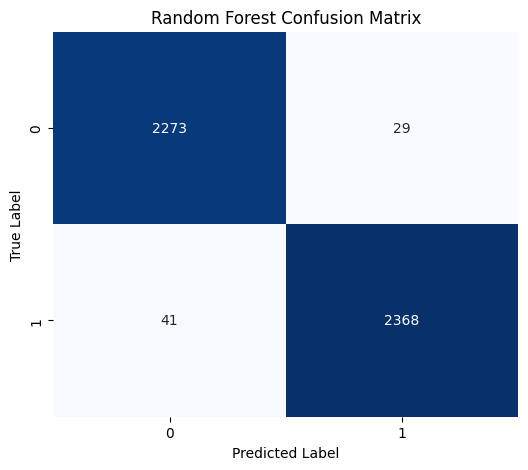

Saved: ../controller/models_dist/rf_model_big.pkl


In [5]:
print("\nTraining Random Forest...")

# Train
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred_rf)
print(f" Random Forest Accuracy: {acc*100:.2f}%\n")

# Precision, Recall, and F1-Score
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Attack']))

# Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Save Model
joblib.dump(rf_model, f"{MODELS_DIR}/rf_model_big.pkl")
print(f"Saved: {MODELS_DIR}/rf_model_big.pkl")


Training Isolation Forest...
 Isolation Forest Trained.
 Isolation Forest Accuracy: 80.60%

--- Isolation Forest Classification Report ---
              precision    recall  f1-score   support

      Benign       0.80      0.81      0.80      2302
      Attack       0.82      0.80      0.81      2409

    accuracy                           0.81      4711
   macro avg       0.81      0.81      0.81      4711
weighted avg       0.81      0.81      0.81      4711



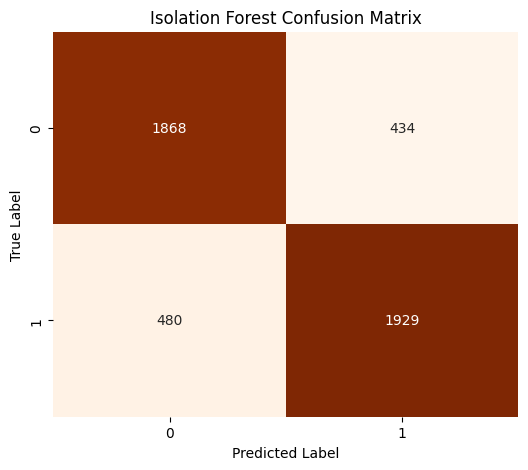

 Saved: ../controller/models_dist/iso_model_big.pkl


In [6]:
print("\nTraining Isolation Forest...")

# Unsupervised training
iso_model = IsolationForest(contamination=0.5, random_state=42, n_jobs=-1)
iso_model.fit(X_train)

print(" Isolation Forest Trained.")

# Evaluate the Unsupervised Model
y_pred_iso_raw = iso_model.predict(X_test)
y_pred_iso = np.where(y_pred_iso_raw == 1, 0, 1)

iso_acc = accuracy_score(y_test, y_pred_iso)
print(f" Isolation Forest Accuracy: {iso_acc*100:.2f}%\n")

print("--- Isolation Forest Classification Report ---")
print(classification_report(y_test, y_pred_iso, target_names=['Benign', 'Attack']))

# Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_iso), annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Isolation Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Save Model
joblib.dump(iso_model, f"{MODELS_DIR}/iso_model_big.pkl")
print(f" Saved: {MODELS_DIR}/iso_model_big.pkl")